## Demonstation of fNIRS data properties

This code uses two python packages (and their dependancies).  The first is Cedalion which is developed by the Alex von Luhmann's group in Berlin.  
https://github.com/ibs-lab/cedalion

My code, called pyNIRS_toolbox builds on top of Cedalion to expose easier to use versions of the tools.
https://github.com/huppertt/pyNIRS_toolbox

My python code is a port of my Matlab toolbox (https://github.com/huppertt/nirs-toolbox).

Because Cedalion is not on pip, you need to install this from their GitHub repo.  Their requirements file was not entirely complete, but I think the requirements file from mine will fix all the issues.


In [1]:
import sys

import pyBrainAnalyzIR

import pyBrainAnalyzIR.testing.simData
import pyBrainAnalyzIR.testing.simEvents
from pyBrainAnalyzIR.vis.plot_nirs_inline import plot as nirs_show

import matplotlib.pyplot as plt
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf
import pandas as pd


# This will allow matplotlib to work as a widget (needs "pip install ipympl")
# %matplotlib widget

# Simulating data
It is probably easiest to start with just simulated data.  

This is my paper describing the noise properties of typical fNIRS data

Huppert, Theodore J. "Commentary on the statistical properties of noise and its implication on general linear models in functional near-infrared spectroscopy." Neurophotonics 3.1 (2016): 010401-010401.

https://www.spiedigitallibrary.org/journalArticle/Download?fullDOI=10.1117/1.NPh.3.1.010401



In [2]:
noise=pyBrainAnalyzIR.testing.simData.ARnoise()

# This function will simulate fNIRS CW raw amp data with AR noise
#    This matches the defaults for the nirs toolbox nirs.modules.simARNoise
#    
#    Inputs:
#        geo2d.  2d probe structure.     {Default calls defaultProbe()}
#        measList: Dictionary containing {Default calls defaultProbe()}
#                channel: xr.DataArray
#                wavelength: List[float]
#        t:      time variable.  np.array {Default 0-300s @ 10Hz}
#        P:      AR model order (calls randAR(P) to generate) {default 10}
#        sigma:  Spatial covariance noise prior {default 0.33}
#
#    Outputs:
#        rec:    Cedalion recording structure 


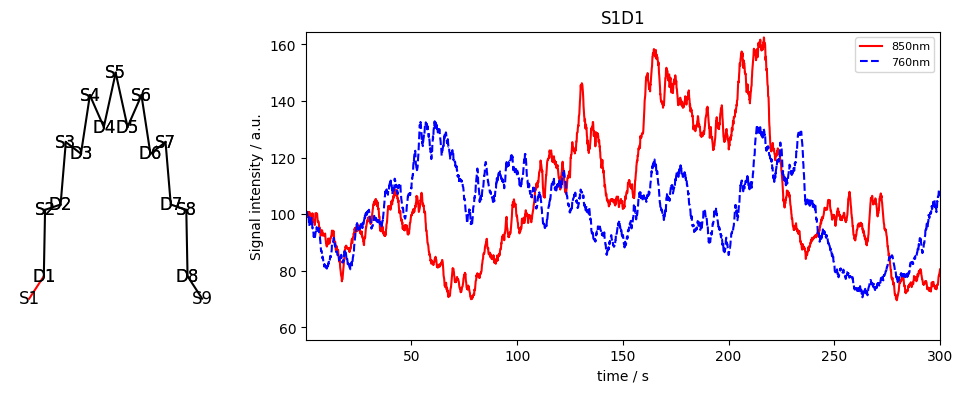

In [3]:
# Display the simulated AR noise data using the inline NIRS plot function
nirs_show(noise,'amp')

# This is actually an interactive plot if you uncomment the line (# %matplotlib widget) in the header of this notebook (leave the "%").  However, if you display this as an interactive plot, the other static plots have issues sometimes.  I need to fix that.

/opt/anaconda3/envs/NIRS/lib/python3.13/site-packages/xarray/core/variable.py:315: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


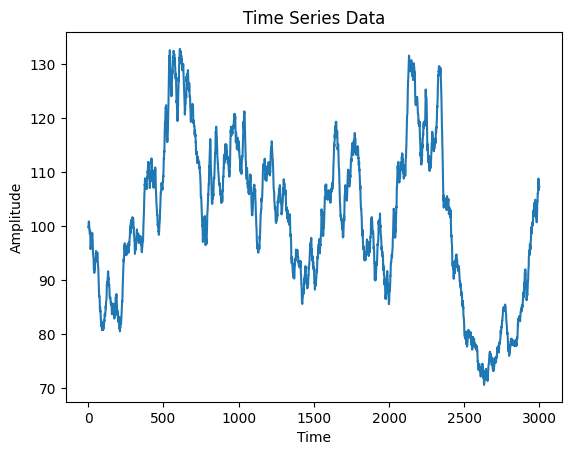

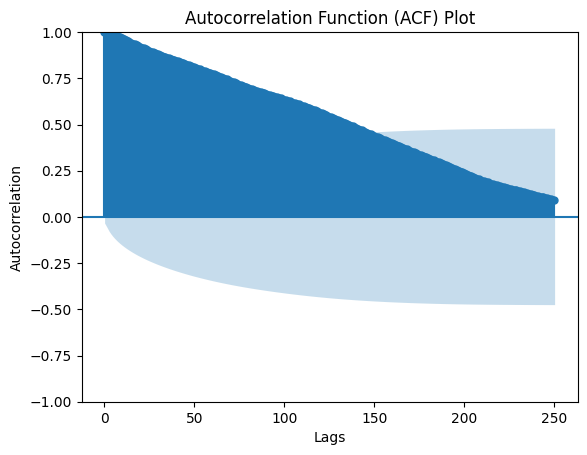

In [4]:
data = noise['amp'].values[:,0,0]

# Ignore the warning about UnitStripping.  Cedalion uses pints units to label everything and it's a bit of an overkill.  

plt.plot(data)
plt.title("Time Series Data")
plt.xlabel("Time")
plt.ylabel("Amplitude")


plot_acf(data, lags=250)
plt.title("Autocorrelation Function (ACF) Plot")
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.show()


In [5]:
# Here is anouther version of the simulate data, this one will add Task driven events (brain activity) and I am also using the modifier to add motion artifacts in the data

noise_motion,_=pyBrainAnalyzIR.testing.simData.Data(snr=10,modifiers=[pyBrainAnalyzIR.testing.simData.simMotionArtifact])

 94%|█████████▍| 15/16 [00:00<00:00, 3177.82it/s]


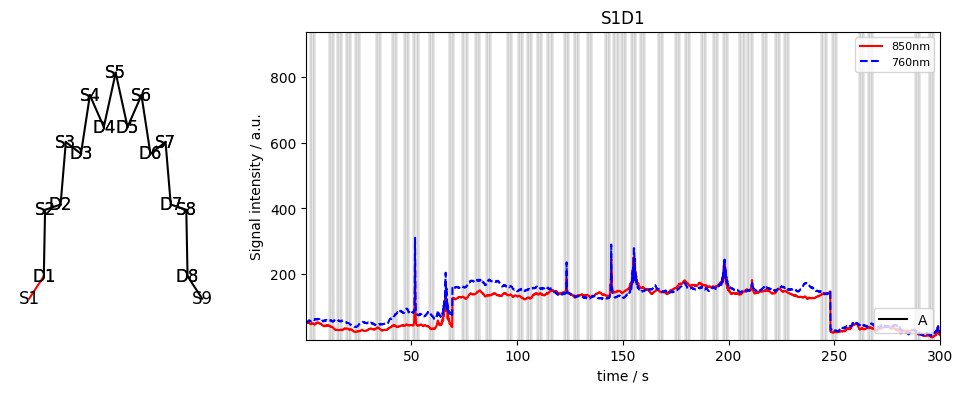

In [6]:
nirs_show(noise_motion,'amp')

# Here we have a single stimulus (task) condition called "A".  The veritical lines show the timing of the task events.  In our first level statistical analysis, a regression model based on the timing of these events is used and the resulting beta coefficients reflect the task-related brain activity (i.e., the brain's response to the task).  The challenges are 1) the data is very heavy tailed, 2) there are high levels of autocorrelated noise, and 3) the evoked responses are very small (typically < 1% signal change).
 


In [7]:
stim = pyBrainAnalyzIR.testing.simEvents.blocked_stim_design(block_dur=20, block_space=20, ncond=2)

sim_data,truth=pyBrainAnalyzIR.testing.simData.Data(snr=10,stim=stim)

 94%|█████████▍| 15/16 [00:00<00:00, 889.74it/s]


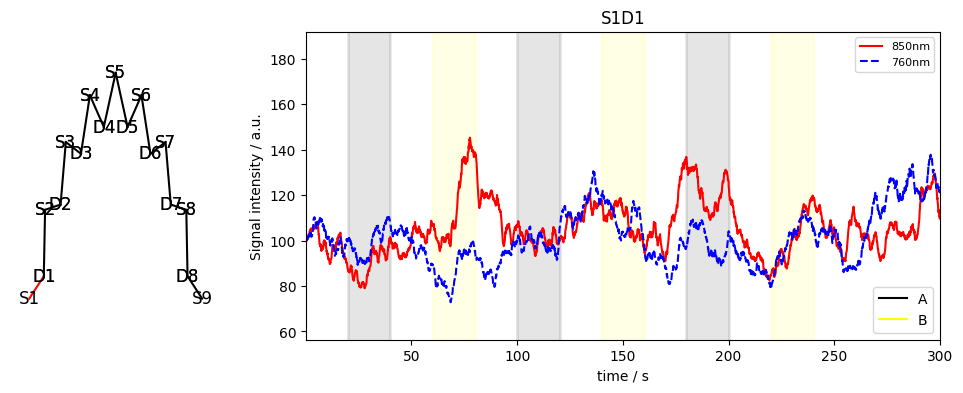

In [8]:
nirs_show(sim_data,'amp')

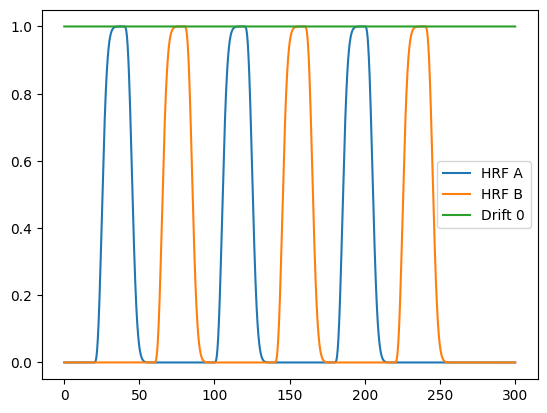

In [32]:
import cedalion.models.glm as glm
import cedalion
units = cedalion.units

data = sim_data['amp']
stim = sim_data.stim

# To get access to the standard regressors for the regression/stats model, we have to use the backend of Cedalion a bit.  It is a bit more complex than using my code

design_matrix = (
        glm.design_matrix.hrf_regressors(
            data, stim, glm.Gamma(tau=0 * units.s, sigma=5 * units.s)
        )
        & glm.design_matrix.drift_regressors(data, drift_order=0)
    )

# Cedalion stores a potentially diffrent design matrix for each channel, which is why this comes out as a tensor instead of just a time x regressor matrix.  For our, matrix will be the same on all channels so we can just ignore the third dimension

time = data.time
X=design_matrix.common[:,:,0]
plt.plot(time,X)
plt.legend(design_matrix.common.regressor.values)
